<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/ExamPrep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 14.5 MB/s eta 0:00:00


In [16]:
import os

from IPython.display import Image
from google.colab import userdata
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command, Send
from langchain_core.prompts import PromptTemplate
from typing import Annotated, Dict, List, Literal, TypedDict
from pydantic import BaseModel

os.environ["LANGSMITH_TRACING"]="true"
os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')
os.environ["LANGSMITH_PROJECT"] = "AlgResearch"

openai_api_key = userdata.get('OPENAI_API_KEY')
openrouter_api_key = userdata.get('OPENROUTER_API_KEY')

In [51]:
class Algorithm(BaseModel):
    name: str
    description: str
    time_complexity: str
    memory_complexity: str

class AlgorithmResearchResponse(BaseModel):
    algorithms: List[Algorithm]


class DesignInterfaceResponse(BaseModel):
    interface: str

class SystemState(TypedDict):
    problem_description: str

    # research should propose algorithm:
    algorithms: List[Algorithm]

    # TODO: Maybe we need to store the "Design interface" conversation history.
    interfaces: str
    tests: str
    implementations: Dict[str, str] # key: name of alg, value: main implementation

In [52]:
research_agent = create_agent(
    model = ChatOpenAI(model = "gpt-5.4-mini", api_key = openai_api_key, reasoning_effort = "low"),
    tools = [{"type": "web_search"}],
    system_prompt = (
        "You are a senior algorithms researcher. Given a problem, use web search to consult "
        "authoritative references (textbooks, competitive-programming resources, academic notes) "
        "and then produce a thorough survey of solution approaches.\n\n"
        "Hard requirements:\n"
        "- Propose AT LEAST three meaningfully different algorithms - different paradigms, "
        "  data structures, or complexity profiles. Variants of the same idea do not count.\n"
        "- For each algorithm provide a detailed natural-language description of how it works.\n"
        "- Do NOT include code. Do NOT include pseudo-code. Prose only.\n"
        "- Discuss intuition, main steps, data structures, preconditions, and trade-offs.\n"
        "- State time and space complexity with a one-line justification."
    ),
    response_format = AlgorithmResearchResponse
)


architect_agent = create_agent(
    model= ChatOpenAI(model = "inception/mercury-2.5", api_key = openrouter_api_key, base_url = "https://openrouter.ai/api/v1"),
    tools = [], # TODO: Compile/Validate tool
    system_prompt = (
        "You are a senior C# API designer. Produce a single C# interface that every researched "
        "algorithm could implement The interface must be:\n"
        "- Minimal but sufficient for all approaches.\n"
        "- Easily testable: deterministic, side-effect free, value-based inputs and outputs, no hidden global state, no I/O.\n"
        "- Use immutable types or simple value types for inputs and outputs where possible.\n"
        "- Use modern C# (file-scoped namespace, nullable enabled).\n"
        "- Namespace: AlgorithmResearch.Contracts.\n"
        "Return the full file contents in C#."
    ),
    response_format = DesignInterfaceResponse
)

In [53]:
def format_algorithms(algorithms: List[Algorithm]) -> str:
    return "\n=========\n".join(f"Algorithm {idx + 1}: {alg.name}\n{alg.description}" for idx, alg in enumerate(algorithms))

In [54]:
def empty_fn(state: SystemState) -> None:
    pass


def research(state: SystemState):
    problem_description = state["problem_description"]

    # agent
    proposed_algorithms = research_agent.invoke(
        input = {
            "messages": [HumanMessage(content=f"Problem Description:\n{problem_description}")]
        }
    )

    return { "algorithms": proposed_algorithms['structured_response'].algorithms }

def design_interface(state: SystemState):
    problem_description = state["problem_description"]
    algorithms = state['algorithms']

    # да се обърнем към агент - на който да кажем описанието на проблема, това са алгоритмите - като агент да предостави c# решения на алгоритмите
    proposed_interface = architect_agent.invoke(
        input = {
            "messages": [HumanMessage(content=f"Problem Description:\n{problem_description}\n\n{format_algorithms(algorithms)}")]
        }
    )

    return {"interface": proposed_interface['structured_response'].interface }

def delegate_tasks(state: SystemState):
    return END

In [55]:
graph_builder = StateGraph(SystemState)
graph_builder.add_node("Research", research);
graph_builder.add_node("Design interface", design_interface);
graph_builder.add_node("QA", empty_fn);
graph_builder.add_node("Dev", empty_fn);

graph_builder.add_edge(START, "Research")
graph_builder.add_edge("Research", "Design interface")

graph_builder.add_conditional_edges("Design interface", delegate_tasks, ["Design interface", "QA", "Dev", END])

graph_builder.add_edge("QA", END)
graph_builder.add_edge("Dev", END)

graph = graph_builder.compile(debug = True)

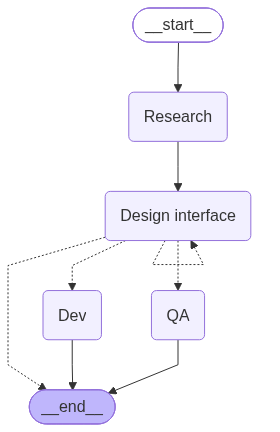

In [56]:
display(Image(data=graph.get_graph().draw_mermaid_png(), format = "png"))

In [57]:
graph.invoke(
    input = {
        "problem_description": "I have a large binary search three. How can I find the nearest common ancestor for two nodes?"
    }
)

[values] {'problem_description': 'I have a large binary search three. How can I find the nearest common ancestor for two nodes?'}
[updates] {'Research': {'algorithms': [Algorithm(name='Top-down descent from the root using BST ordering', description='This is the standard BST-specific method. Start at the root and compare the two target keys with the current node’s key. If both targets are smaller, the nearest common ancestor must lie entirely in the left subtree; if both are larger, it must lie in the right subtree. The first node where the two targets split to different sides is the answer, and if the current node equals one of the targets, that node is also the nearest common ancestor. The key precondition is that the tree really is a binary search tree and that node keys are comparable. This works because the BST ordering guarantees that every ancestor on the search paths to both nodes must lie on the unique root-to-node paths, and the first divergence point is the deepest shared anc

{'problem_description': 'I have a large binary search three. How can I find the nearest common ancestor for two nodes?',
 'algorithms': [Algorithm(name='Top-down descent from the root using BST ordering', description='This is the standard BST-specific method. Start at the root and compare the two target keys with the current node’s key. If both targets are smaller, the nearest common ancestor must lie entirely in the left subtree; if both are larger, it must lie in the right subtree. The first node where the two targets split to different sides is the answer, and if the current node equals one of the targets, that node is also the nearest common ancestor. The key precondition is that the tree really is a binary search tree and that node keys are comparable. This works because the BST ordering guarantees that every ancestor on the search paths to both nodes must lie on the unique root-to-node paths, and the first divergence point is the deepest shared ancestor. ([leetcode.com](https://l